***** RED NEURONAL CON TECNICAS DE REGULARIZACIÓN **** 

DATASET
Datos de entrenamiento: (400, 2)
Datos de prueba: (100, 2)
Funcion de activación: ReLu
Optimizador: Gradiente SGD


 * Primer entrenamiento: Modelo SIN regularización*
λ: 0.0 - Epoca 0 - Perdida: 0.6962
λ: 0.0 - Epoca 200 - Perdida: 0.2952
λ: 0.0 - Epoca 400 - Perdida: 0.2828
λ: 0.0 - Epoca 600 - Perdida: 0.2808
λ: 0.0 - Epoca 800 - Perdida: 0.2800
λ: 0.0 - Epoca 1000 - Perdida: 0.2792
λ: 0.0 - Epoca 1200 - Perdida: 0.2788
λ: 0.0 - Epoca 1400 - Perdida: 0.2785
λ: 0.0 - Epoca 1600 - Perdida: 0.2782
λ: 0.0 - Epoca 1800 - Perdida: 0.2779
λ: 0.0 - Epoca 1999 - Perdida: 0.2773


 * Segundo entrenamiento: Modelo CON regularización L2*
λ: 0.1 - Epoca 0 - Perdida: 0.6007
λ: 0.1 - Epoca 200 - Perdida: 0.3342
λ: 0.1 - Epoca 400 - Perdida: 0.2886
λ: 0.1 - Epoca 600 - Perdida: 0.2753
λ: 0.1 - Epoca 800 - Perdida: 0.2688
λ: 0.1 - Epoca 1000 - Perdida: 0.2648
λ: 0.1 - Epoca 1200 - Perdida: 0.2622
λ: 0.1 - Epoca 1400 - Perdida: 0.2605
λ

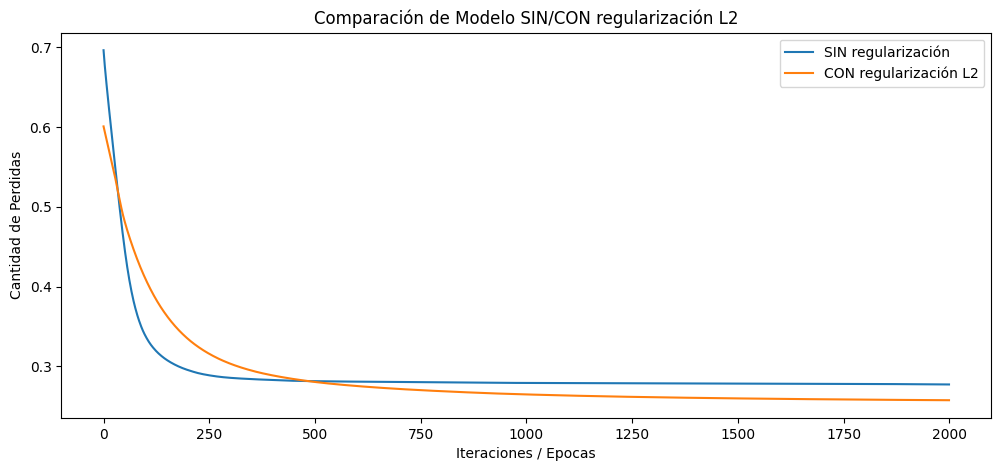

In [17]:
# Importacion de librerias necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


print("***** RED NEURONAL CON TECNICAS DE REGULARIZACIÓN **** \n")

# Creacion del Dataset de datos
np.random.seed(42)
datos_entrada, etiquetas = make_moons(n_samples=500, noise=0.2) #500 datos iniciales
etiquetas = etiquetas.reshape(-1,1) #Si es dato de entrenamiento o prueba

datos_entrenamiento, datos_prueba, etiquetas_entrenamiento, etiquetas_prueba = train_test_split(
    datos_entrada, etiquetas, test_size=0.2, random_state=42
)

print("DATASET")
print("Datos de entrenamiento:", datos_entrenamiento.shape) #Resultado total cantidad datos para entrenamiento
print("Datos de prueba:", datos_prueba.shape) #Resultado total cantidad datos para pruebas
print("Funcion de activación: ReLu")
print("Optimizador: Gradiente SGD")


# Funciones de activacion (Sigmoid y ReLU)
def sigmoid(x):
    return 1/(1+np.exp(-x))

def derivada_sigmoid(x):
    s = sigmoid(x)
    return s*(1-s)

def relu(x):
    return np.maximum(0,x)

def derivada_relu(x):
    return (x>0).astype(float)


# Funcion Inicializar parametros
def inicializar_parametros():
    pesos_capa_oculta = np.random.randn(2,4)*0.5  #Genera 2 entrada con 4 pesos aletorios para cada capa oculta por entrada
    sesgos_capa_oculta = np.zeros((1,4))

    pesos_capa_salida = np.random.randn(4,1)*0.5  #Genera 4 pesos aletorios para cada capa oculta por salida
    sesgos_capa_salida = np.zeros((1,1))

    return pesos_capa_oculta, sesgos_capa_oculta, pesos_capa_salida, sesgos_capa_salida


#Funcion Feedforward (Propagacion hacia adelante)
def propagacion_adelante(datos_entrada, pesos_capa_oculta, sesgos_capa_oculta, pesos_capa_salida, sesgos_capa_salida, activacion):

    suma_capa_oculta = datos_entrada.dot(pesos_capa_oculta) + sesgos_capa_oculta   #Calculo de capas ocultas (x1*w1 + x2*w2) + sesgo

    #Aplicamos la funcion de activacion al calculo de la capa oculta de entrada
    if activacion == "sigmoid":
        activacion_capa_oculta = sigmoid(suma_capa_oculta) #h1 = sigmoid(suma_capa_oculta)
    else:
        activacion_capa_oculta = relu(suma_capa_oculta)

    suma_capa_salida = activacion_capa_oculta.dot(pesos_capa_salida) + sesgos_capa_salida  #Calculo de capas de salida (h1*w1 + h2*w2 + h3*w3 + h4*w4)
    salida_predicha = sigmoid(suma_capa_salida)   #ŷ = sigmoid(suma_capa_salida) Prediccion

    return suma_capa_oculta, activacion_capa_oculta, suma_capa_salida, salida_predicha


#Funcion Calculo de perdida - Loss (realidad vs predicción)
def calcular_perdida(etiquetas_reales, salida_predicha, pesos_capa_oculta, pesos_capa_salida, regularizacion_lambda_L2):

    numero_muestras = etiquetas_reales.shape[0]

    perdida = -(1/numero_muestras)*np.sum(
        etiquetas_reales*np.log(salida_predicha+1e-8) +
        (1-etiquetas_reales)*np.log(1-salida_predicha+1e-8)
    )   #Obtener porcentaje de perdida

    # Modelo de Regularización L2
    regularizacion = (regularizacion_lambda_L2/(2*numero_muestras)) * (
        np.sum(np.square(pesos_capa_oculta)) +
        np.sum(np.square(pesos_capa_salida))
    )

    return perdida + regularizacion


#Funcion Backpropagation (Propagación del error hacia atrás)
def retropropagacion(datos_entrada, etiquetas_reales, suma_capa_oculta, activacion_capa_oculta, salida_predicha, pesos_capa_oculta, pesos_capa_salida, activacion, regularizacion_lambda_L2):

    numero_muestras = datos_entrada.shape[0]

    error_salida = salida_predicha - etiquetas_reales   #error = predicción - valor_real

    #Cada peso recibe un gradiente que indica cuánto debe cambiar
    gradiente_pesos_salida = (1/numero_muestras)*activacion_capa_oculta.T.dot(error_salida) + (regularizacion_lambda_L2/numero_muestras)*pesos_capa_salida  #gradiente_pesos = derivada_normal || gradiente_pesos = derivada_normal + (lambda_l2/n)*pesos
    gradiente_sesgos_salida = (1/numero_muestras)*np.sum(error_salida,axis=0,keepdims=True)
    error_capa_oculta = error_salida.dot(pesos_capa_salida.T)

    #Aplicar funcion de activación
    if activacion=="sigmoid":
        gradiente_suma_oculta = error_capa_oculta*derivada_sigmoid(suma_capa_oculta)
    else:
        gradiente_suma_oculta = error_capa_oculta*derivada_relu(suma_capa_oculta)

    gradiente_pesos_oculta = (1/numero_muestras)*datos_entrada.T.dot(gradiente_suma_oculta) + (regularizacion_lambda_L2/numero_muestras)*pesos_capa_oculta  #gradiente_pesos = derivada_normal || gradiente_pesos = derivada_normal + (lambda_l2/n)*pesos
    gradiente_sesgos_oculta = (1/numero_muestras)*np.sum(gradiente_suma_oculta,axis=0,keepdims=True)

    return gradiente_pesos_oculta, gradiente_sesgos_oculta, gradiente_pesos_salida, gradiente_sesgos_salida


# Funcion de Entrenamiento de Red Neuronal con 2000 epocas por defecto
def entrenar_red(datos_entrenamiento, etiquetas_entrenamiento, activacion, optimizador="sgd", regularizacion_lambda_L2=0.0, epocas=2000, tasa_aprendizaje=0.1):

    #Obtenemos parametros de entrada (inicializar pesos y sesgo)
    pesos_capa_oculta, sesgos_capa_oculta, pesos_capa_salida, sesgos_capa_salida = inicializar_parametros()

    historial_perdida = []

   #Iteramos epoca por epoca (2000 en total)
    for epoca in range(epocas):

        #Forward Pass - Propagación hacia adelante para calculan las salidas de la red neuronal
        suma_capa_oculta, activacion_capa_oculta, suma_capa_salida, salida_predicha = propagacion_adelante(
            datos_entrenamiento, pesos_capa_oculta, sesgos_capa_oculta, pesos_capa_salida, sesgos_capa_salida, activacion
        )

        #Cálculo de la pérdida (Loss)
        perdida = calcular_perdida(
            etiquetas_entrenamiento, salida_predicha, pesos_capa_oculta, pesos_capa_salida, regularizacion_lambda_L2
        )

        #Backpropagation - Retropropagación del error para ajustar los pesos de la red neuronal y minimizar el error de predicción
        gradiente_pesos_oculta, gradiente_sesgos_oculta, gradiente_pesos_salida, gradiente_sesgos_salida = retropropagacion(
            datos_entrenamiento, etiquetas_entrenamiento, suma_capa_oculta, activacion_capa_oculta, salida_predicha, pesos_capa_oculta, pesos_capa_salida, activacion, regularizacion_lambda_L2
        )

        # ===== Aplicar tecnicas de Optimizadores =====

        if optimizador == "sgd": # Gradiante SGD básico
            #Ajuste de los pesos (nuevo_peso = peso_actual − learning_rate × gradiente)
          pesos_capa_oculta -= tasa_aprendizaje*gradiente_pesos_oculta
          sesgos_capa_oculta -= tasa_aprendizaje*gradiente_sesgos_oculta
          pesos_capa_salida -= tasa_aprendizaje*gradiente_pesos_salida
          sesgos_capa_salida -= tasa_aprendizaje*gradiente_sesgos_salida


        elif optimizador == "sgd_with_lrdecay": # SGD con Learning rate decay
            decaimiento_tasa_aprendizaje = tasa_aprendizaje / (1 + 0.001 * epoca)

            #Ajuste de los pesos (nuevo_peso = peso_actual − learning_rate_decay × gradiente)
            pesos_capa_oculta -= decaimiento_tasa_aprendizaje*gradiente_pesos_oculta
            sesgos_capa_oculta -= decaimiento_tasa_aprendizaje*gradiente_sesgos_oculta
            pesos_capa_salida -= decaimiento_tasa_aprendizaje*gradiente_pesos_salida
            sesgos_capa_salida -= decaimiento_tasa_aprendizaje*gradiente_sesgos_salida

        # ===== Fin de Aplicar tecnicas de Optimizadores =====

        historial_perdida.append(perdida)

        if (epoca % 200 == 0) or (epoca == 1999):
            print(f"λ: {regularizacion_lambda_L2} - Epoca {epoca} - Perdida: {perdida:.4f}")

    return historial_perdida


#Primer aprendizaje con Optimizador SGD
print("\n\n * Primer entrenamiento: Modelo SIN regularización*")
perdida = entrenar_red(
    datos_entrenamiento, etiquetas_entrenamiento, activacion="relu", optimizador="sgd", regularizacion_lambda_L2=0.0
) #Entrenamos la red indicando la funcion de activacion, optimizador y modelo de regularización

#Segundo aprendizaje con Optimizador Learning Rate Decay
print("\n\n * Segundo entrenamiento: Modelo CON regularización L2*")
perdida_regularizacion_L2 = entrenar_red(
    datos_entrenamiento, etiquetas_entrenamiento, activacion="relu", optimizador="sgd", regularizacion_lambda_L2=0.1
)


#Graficamos la comparativa entre funciones de activacion y su evolucion de perdida
print("\n\n")
plt.figure(figsize=(12,5))
plt.plot(perdida, label="SIN regularización")
plt.plot(perdida_regularizacion_L2, label="CON regularización L2")
plt.title("Comparación de Modelo SIN/CON regularización L2")
plt.xlabel("Iteraciones / Epocas")
plt.ylabel("Cantidad de Perdidas")
plt.legend()
plt.show()



# **Red Neuronal con Tecnicas de Regularización**

Para este algoritmo se agregaron dos entradas X1, X2, cuatro capas ocultas H1, H2, H3, H4 y una salida. Los datos de entrada y etiquetas se generan una unica vez desde un dataset de numpy.
Este modelo emplea la funcion de activación ReLu, el optimizador Gradiante SGD y los mismos datos de entrada para cada regularización (con o sin L2) para asi poder realizar una comparacion valida.

Dataset ──► Forward Pass ──► Predicción ──► Cálculo de error (regularización L2) ──► Backpropagation (regularización L2 en gradiantes) ──► Ajuste de pesos con Optimizadores (SGD) ──► Repetir 2000 veces ──► Modelo entrenado

De acuerdo a esto y realizando un analisis de comparación se puede concluir que:
- El **uso de regularización L2** reduce el overfitting y hace el entrenamiento más estable, limitando el crecimiento de los pesos y mejorando la capacidad de generalización del modelo.
- El parámetro λ en la regularización L2 controla la intensidad de la penalización sobre los pesos del modelo. En este codigo se probaron diferentes valores (por ejemplo 0.1, 0.001 y 1) concluyendo que valores excesivos pueden provocar underfitting.
- El **NO uso de regularización L2** permite que los pesos crezcan libremente, lo que mejora el ajuste a los datos de entrenamiento, pero aumenta el riesgo de capturar ruido y reducir el desempeño en datos de prueba.

Esto evidencia la importancia de aplicar una tecnica de regularización y ajustar los hiperparámetros λ adecuadamente según el problema.

***Nota:** Para ajustar a gusto el valor de λ en el codigo verifique la variable "regularizacion_lambda_L2".*
